In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"]=(20,10)
import seaborn as sns;sns.set()
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from datetime import datetime,time
from plotly.offline import iplot,plot,init_notebook_mode,download_plotlyjs
%matplotlib inline 
init_notebook_mode(connected=True)
import math

In [ ]:
from Constants import PATH
PATH=PATH
import os
os.chdir(PATH)

In [ ]:
df=pd.read_csv("Data_Sets/data_set_for_stats.csv")
df['week_start_dt']=pd.to_datetime(df['week_start_dt'])
df['week_end_dt']=pd.to_datetime(df['week_end_dt'])

numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include='object').columns.tolist()
boolean_cols=df.select_dtypes(include='bool').columns.tolist()
date_cols=df.select_dtypes(include='datetime').columns.tolist()

print(f"numerical_cols : \n{numerical_cols}")
print("--------------------------------------------------")
print(f"categorical_cols : \n{categorical_cols}")
print("--------------------------------------------------")
print(f"boolean_cols : \n{boolean_cols}")
print("--------------------------------------------------")
print(f"date_cols : \n{date_cols}")

numerical_cols : 
['vietnam_season', 'price', 'total_volume', 'brazil', 'india', 'vietnam', 'indonesia', 'china', 'jordan_max_price', 'jordan_min_price', 'demand', 'supply', 'month', 'year', 'DayOfMonth']
--------------------------------------------------
categorical_cols : 
['p_color']
--------------------------------------------------
boolean_cols : 
['brazil_season', 'indonesia_season', 'india_season', 'china_season']
--------------------------------------------------
date_cols : 
['week_start_dt', 'week_end_dt']


In [ ]:
from scipy.stats import pearsonr, spearmanr, kendalltau
import statsmodels.api as sm
from statsmodels.stats.correlation_tools import corr_nearest, corr_clipped
import warnings
from itertools import combinations
import requests
from io import StringIO

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LinearRegression

from scipy.stats import shapiro
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
import math

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import FTestAnovaPower
import warnings
from itertools import combinations
import requests
from io import StringIO

# Suppress warnings
warnings.filterwarnings('ignore')

# Set visualization style consistent with previous tutorials
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.power import TTestIndPower, TTestPower
import warnings
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu, wilcoxon, ranksums
from scipy.stats import fisher_exact
from scipy.stats import median_test

---

### *Analyzing high-dimensional data characteristics.*

In [ ]:
import os
%pwd
os.chdir("../")
%pwd

'c:\\Users\\Omar\\Desktop\\Omar_Files\\Python_Analysis\\Pepper_Prices_Analysis\\Pepper_Prices_Analysis'

In [ ]:
from utils import analyze_dimensionality
df2=df.copy()
df2=df2[numerical_cols+["p_color"]]
df2['p_color'] = df2['p_color'].replace({'red':0 , 'green':1 , 'yellow':2})

print("\nAnalyzing high-dimensional data characteristics...")
corr_matrix, scale_ratio, high_corr_count, target_corr = analyze_dimensionality(
    data=df2[numerical_cols].values,
    feature_names=numerical_cols,
    target=df2['p_color']
)


Analyzing high-dimensional data characteristics...

Dimensionality Analysis:
Features: 12, Samples: 1215
Sample-to-feature ratio: 101.25

Feature Scale Analysis:
Scale ratio (max/min): 1664526.75
Large scale differences → standardization recommended

Correlation Analysis:
High correlations (|r| > 0.8): 3 (4.5%)

Top features correlated with target:
demand              0.074296
supply              0.063106
price               0.009793
jordan_min_price    0.003997
jordan_max_price    0.003555
dtype: float64


### *visualize_data_structure*


Visualizing data structure...


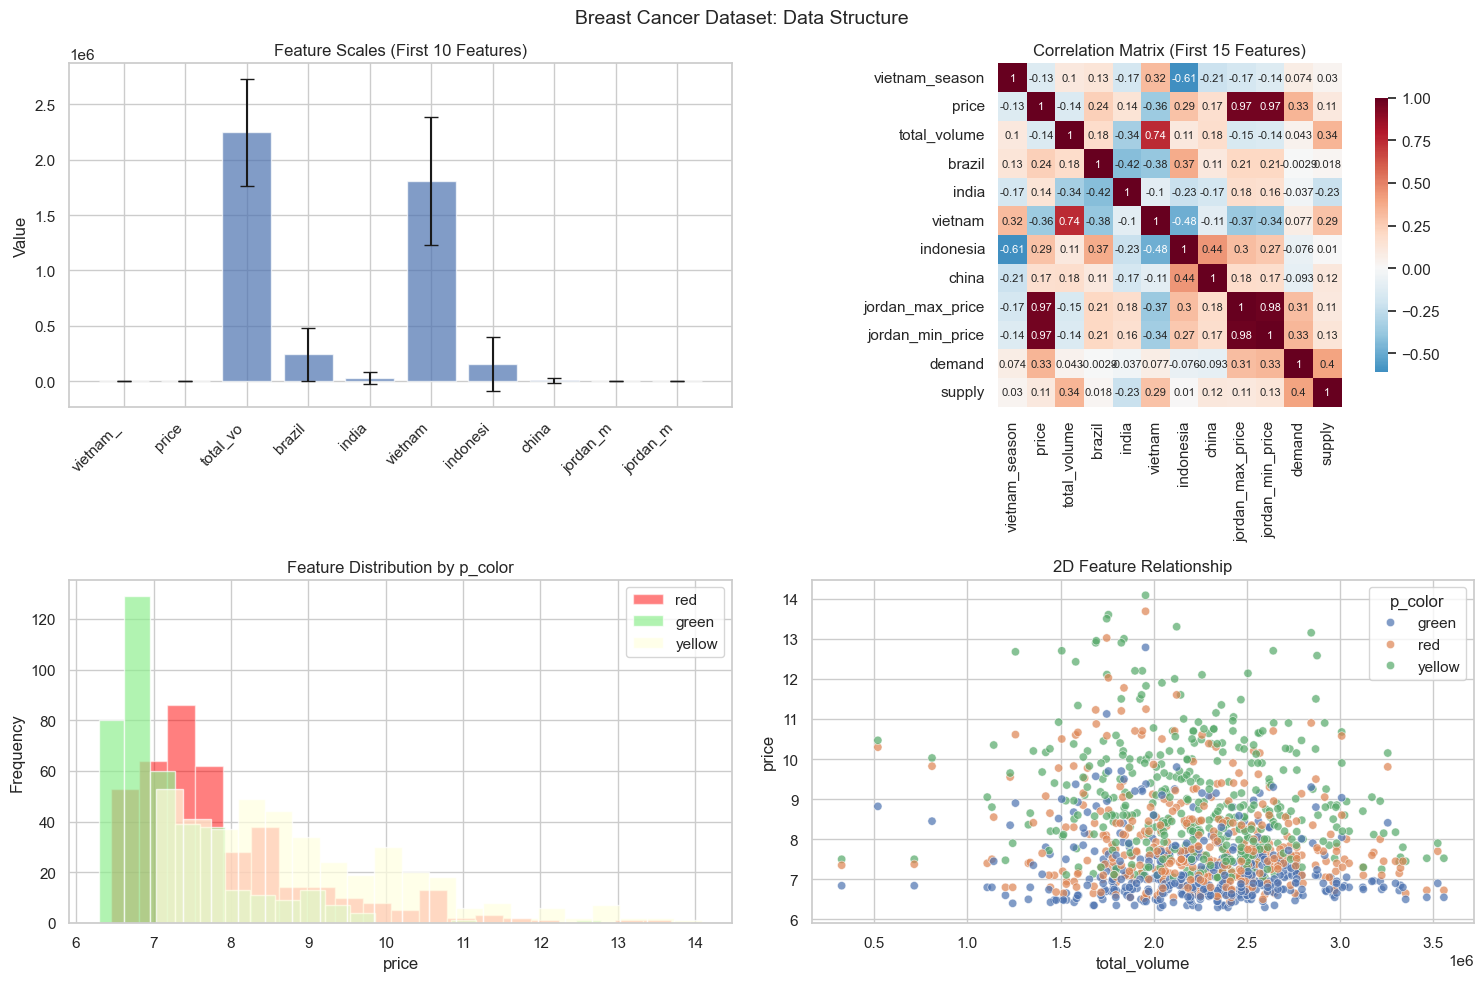

In [ ]:
from utils import visualize_data_structure
df2['p_color'] = df2['p_color'].replace({0:'red' , 1:'green', 2:'yellow'})
print("\nVisualizing data structure...")
visualize_data_structure(df2, numerical_cols)

### *Find and display feature correlations to identify redundancy*

In [ ]:
from utils import find_top_correlations

print("\nFinding feature correlations...")
top_correlations = find_top_correlations(df2, numerical_cols)

print(f"\nSummary:")
print(f"- Dataset has {df2.shape[1]} features with high correlation structure")
print(f"- {high_corr_count} feature pairs are highly correlated (|r| > 0.8)")
print(f"- Large scale differences require standardization")
print(f"- Ready for PCA analysis")


Finding feature correlations...

Top 10 Correlations:
 1. jordan_max_p ↔ jordan_min_p: r =  0.981
 2. price ↔ jordan_min_p: r =  0.968
 3. price ↔ jordan_max_p: r =  0.965
 4. total_volume ↔ vietnam: r =  0.743
 5. vietnam_seas ↔ indonesia: r = -0.612
 6. vietnam ↔ indonesia: r = -0.482
 7. indonesia ↔ china: r =  0.444
 8. brazil ↔ india: r = -0.417
 9. demand ↔ supply: r =  0.404
10. brazil ↔ vietnam: r = -0.381

Summary:
- Dataset has 13 features with high correlation structure
- 3 feature pairs are highly correlated (|r| > 0.8)
- Large scale differences require standardization
- Ready for PCA analysis


### *Data Preproccesing - STANDARDIZATION*

In [ ]:
from sklearn.preprocessing import StandardScaler

from utils import standardize_data

df2['p_color'] = df2['p_color'].replace({'red':0 , 'green':1 , 'yellow':2})

print("=" * 60)
print("DATA STANDARDIZATION")
print("=" * 60)

X_scaled, scaler = standardize_data(df2.values, numerical_cols)

print(f"Original data shape: {df2.shape}")
print(f"Standardized data shape: {X_scaled.shape}")
print(f"All features now have mean ≈ 0 and std ≈ 1")


DATA STANDARDIZATION

Before standardization:
vietnam_season      : mean=    1.92, std=    0.77, range=    2.00
price               : mean=    8.01, std=    1.37, range=    7.78
total_volume        : mean=2244701.29, std=481814.60, range=3230507.80
brazil              : mean=245303.03, std=238434.77, range=877647.80
india               : mean=28744.10, std=55881.80, range=348997.40
vietnam             : mean=1806529.53, std=573594.51, range=3329053.50
indonesia           : mean=154948.08, std=243142.16, range=1061050.80
china               : mean= 8487.64, std=21357.25, range=210920.20
jordan_max_price    : mean=    8.51, std=    1.49, range=    8.00
jordan_min_price    : mean=    7.93, std=    1.37, range=    7.70
demand              : mean=  229.51, std=  225.73, range= 1341.54
supply              : mean=   75.87, std=  113.01, range=  616.15

After standardization:
vietnam_season      : mean=  -0.000, std=   1.000
price               : mean=   0.000, std=   1.000
total_volume       

### *Implement PCA step-by-step to understand the mathematics.*

In [ ]:
from utils import implement_pca_step_by_step
print("\n" + "=" * 60)
print("PCA MATHEMATICAL IMPLEMENTATION")
print("=" * 60)

# Execute PCA step-by-step
pca_results = implement_pca_step_by_step(X_scaled, numerical_cols)


PCA MATHEMATICAL IMPLEMENTATION

PCA Implementation Steps:
Data dimensions: 1215 samples × 13 features

Step 1: Data Centering
Data already centered (standardization sets mean=0)

Step 2: Covariance Matrix
Covariance matrix shape: (13, 13)
Matrix is symmetric: True

Step 3: Eigendecomposition
Eigenvalues sum: 13.01
Expected sum (number of features): 13

Step 4: Variance Explained
Top 10 Principal Components:
PC    Eigenvalue   Var Explained   Cumulative
---------------------------------------------
 1       3.852       0.296       0.296
 2       2.432       0.187       0.483
 3       2.060       0.158       0.641
 4       1.347       0.104       0.745
 5       1.151       0.088       0.833
 6       0.710       0.055       0.888
 7       0.526       0.040       0.928
 8       0.455       0.035       0.963
 9       0.233       0.018       0.981
10       0.190       0.015       0.996

Components needed for variance thresholds:
80% variance:  5 components
90% variance:  7 components
95% v

### *Component Interpretation*

In [ ]:
from utils import analyze_components
print("\n" + "=" * 60)
print("COMPONENT INTERPRETATION")
print("=" * 60)

# Analyze the first 3 components in detail
analyze_components(pca_results, numerical_cols, n_components=3)


COMPONENT INTERPRETATION

Principal Component Analysis:

PRINCIPAL COMPONENT 1:
Eigenvalue: 3.852
Variance explained: 0.296 (29.6%)
Top contributing features:
Feature                 Loading
-----------------------------------
jordan_max_price     + 0.473
price                + 0.472
jordan_min_price     + 0.470
vietnam              - 0.287
indonesia            + 0.257
demand               + 0.202

PRINCIPAL COMPONENT 2:
Eigenvalue: 2.432
Variance explained: 0.187 (18.7%)
Top contributing features:
Feature                 Loading
-----------------------------------
supply               + 0.458
demand               + 0.432
vietnam              + 0.416
total_volume         + 0.361
vietnam_season       + 0.249
indonesia            - 0.203

PRINCIPAL COMPONENT 3:
Eigenvalue: 2.060
Variance explained: 0.158 (15.8%)
Top contributing features:
Feature                 Loading
-----------------------------------
india                - 0.478
indonesia            + 0.453
total_volume         + 0

### *visualize_PCA*


PCA VISUALIZATION

Creating PCA visualizations...


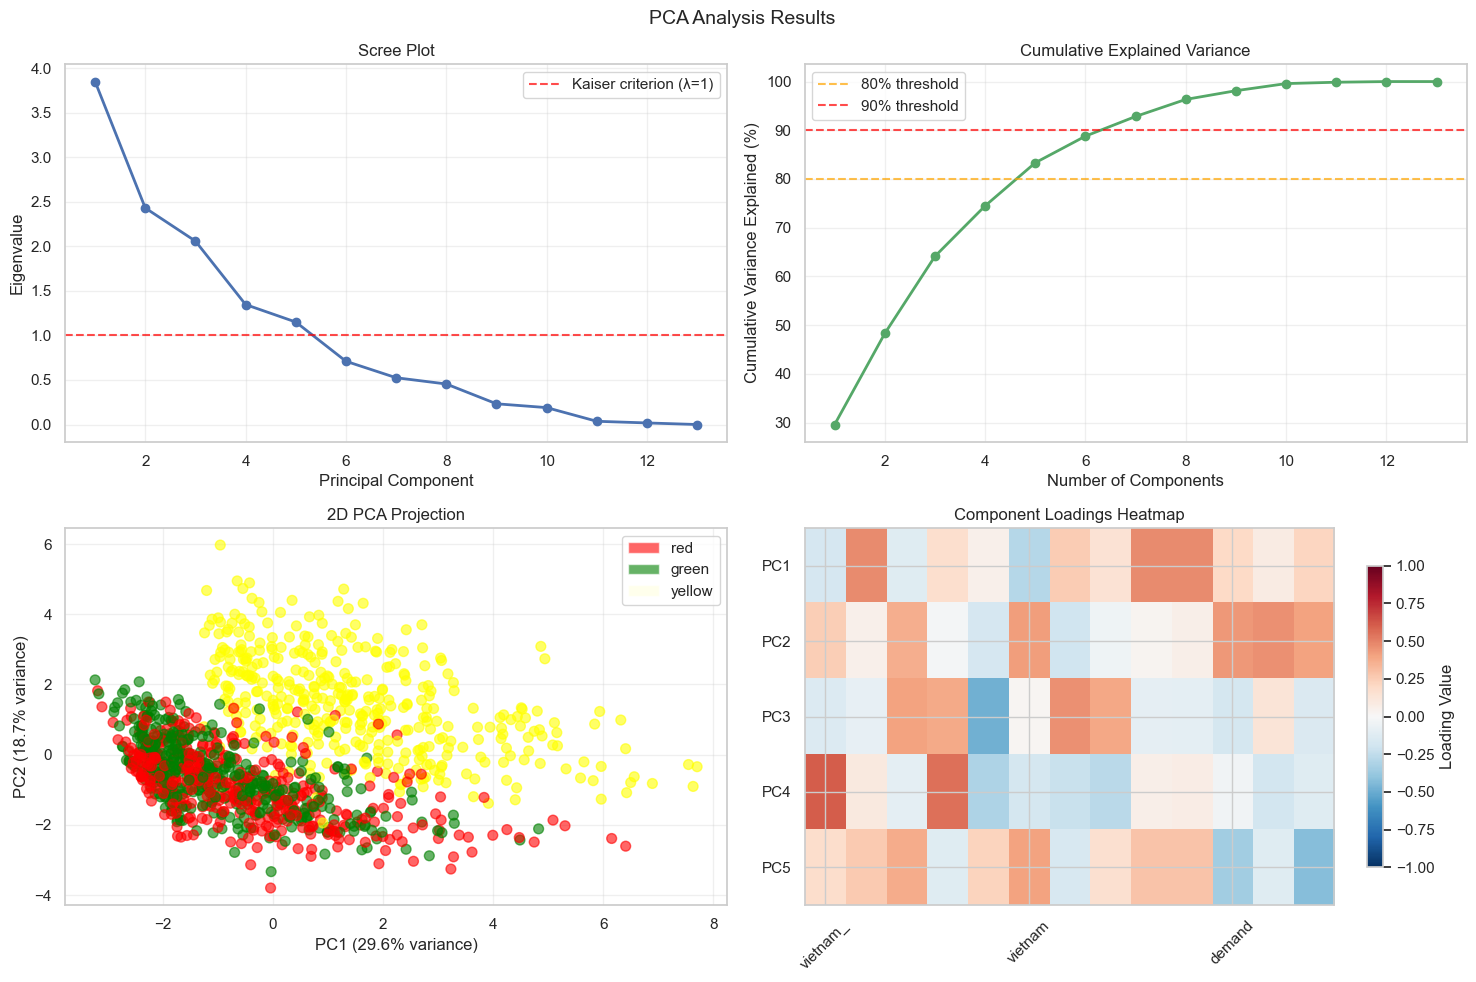


Key Insights:
- 5 components explain 80% of variance
- 7 components explain 90% of variance
- First 2 components explain 48.3% of variance
- Good class separation visible in 2D projection


In [ ]:
from utils import visualize_pca_results
print("\n" + "=" * 60)
print("PCA VISUALIZATION")
print("=" * 60)

# Create all PCA visualizations
pc_80, pc_90 = visualize_pca_results(pca_results, numerical_cols, df2["p_color"], df2['p_color'])

### *Component Selection and Quality Assessment* 

In [ ]:
from utils import select_optimal_components
from mpl_toolkits.mplot3d import Axes3D

print("PCA Tutorial - Part 3: Component Selection and Quality Assessment")
print("-" * 65)

print("\n" + "=" * 60)
print("OPTIMAL COMPONENT SELECTION")
print("=" * 60)

# Analyze different methods for selecting optimal number of components
selection_results = select_optimal_components(pca_results)

print(f"\nComponent selection completed!")
print(f"Final recommendation: {selection_results['final_recommendation']} components")
print(f"This retains {selection_results['variance_at_recommendation']*100:.1f}% of variance")
print(f"Selection methods used: Variance threshold, Kaiser, Scree plot, Interpretability")

PCA Tutorial - Part 3: Component Selection and Quality Assessment
-----------------------------------------------------------------

OPTIMAL COMPONENT SELECTION
Component Selection Methods:

1. Variance Threshold Method:
    80% variance:  5 components
    90% variance:  7 components
    95% variance:  8 components

2. Kaiser Criterion (eigenvalue > 1):
   Components with eigenvalue > 1: 5

3. Scree Plot Elbow:
   Elbow point suggests: 2 components

4. Interpretability Assessment: 5 components

Method Summary:
Method               Components   Variance Retained
--------------------------------------------------
80% variance              5          83.3%
90% variance              7          92.8%
95% variance              8          96.3%
Kaiser criterion          5          83.3%
Scree plot                2          48.3%
Interpretability          5          83.3%

Recommended: 5 components
Balances variance retention (83.3%) with interpretability

Component selection completed!
Final 

### *Create 3D visualization of first three principal components*


3D PCA VISUALIZATION

Creating 3D PCA visualization...


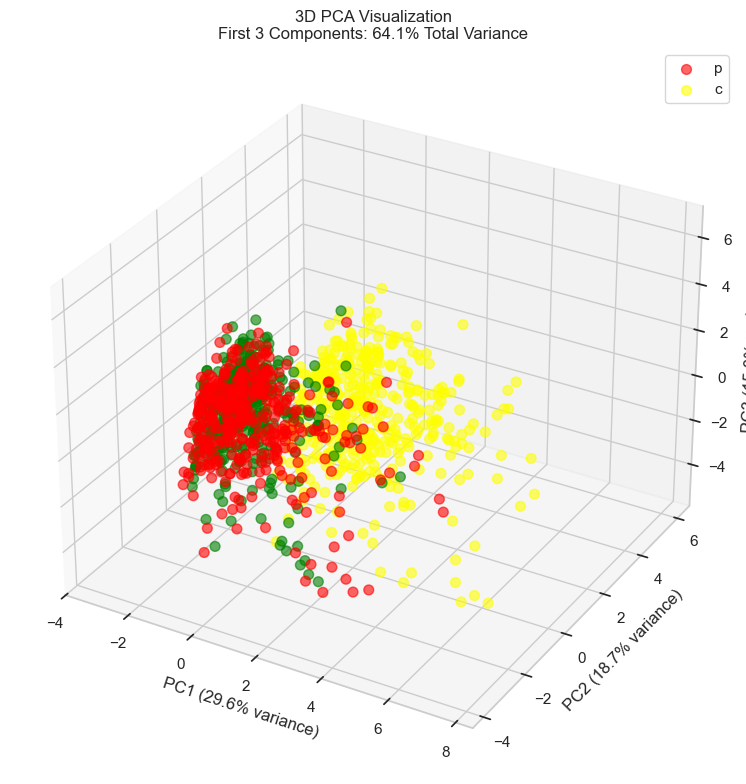

3D Insights:
- First 3 components explain 64.1% of variance
- Clear class separation visible in 3D space
- PC1 provides primary separation axis


In [ ]:
from utils import create_3d_visualization

print("\n" + "=" * 60)
print("3D PCA VISUALIZATION")
print("=" * 60)

# Create 3D visualization of first three components
variance_3d = create_3d_visualization(pca_results, df2["p_color"], 'p_color')

### *Assess PCA quality using reconstruction error.*

In [ ]:
from utils import assess_reconstruction_quality

print("\n" + "=" * 60)
print("RECONSTRUCTION QUALITY ASSESSMENT")
print("=" * 60)

quality_metrics = assess_reconstruction_quality(X_scaled, pca_results, n_components_list=[2, 5, 10, 15])

print(f"Key insight: More components = better reconstruction but less dimensionality reduction")
print(f"Sweet spot balances reconstruction quality with simplicity")


RECONSTRUCTION QUALITY ASSESSMENT

Reconstruction Quality Assessment:
Components  Reconstruction Error  Variance Retained  Info Loss
------------------------------------------------------------
     2                  0.5170              0.483        0.517
     5                  0.1666              0.833        0.167
    10                  0.0042              0.996        0.004
    15                  0.0000              1.000        0.000

Additional Quality Metrics:
Condition number: 4.54e+05
Effective dimensionality: 7.24
Reduction ratio: 1.8x
Key insight: More components = better reconstruction but less dimensionality reduction
Sweet spot balances reconstruction quality with simplicity


### *Visualize reconstruction quality and eigenvalue spectrum*


QUALITY METRICS VISUALIZATION

Creating quality assessment plots...


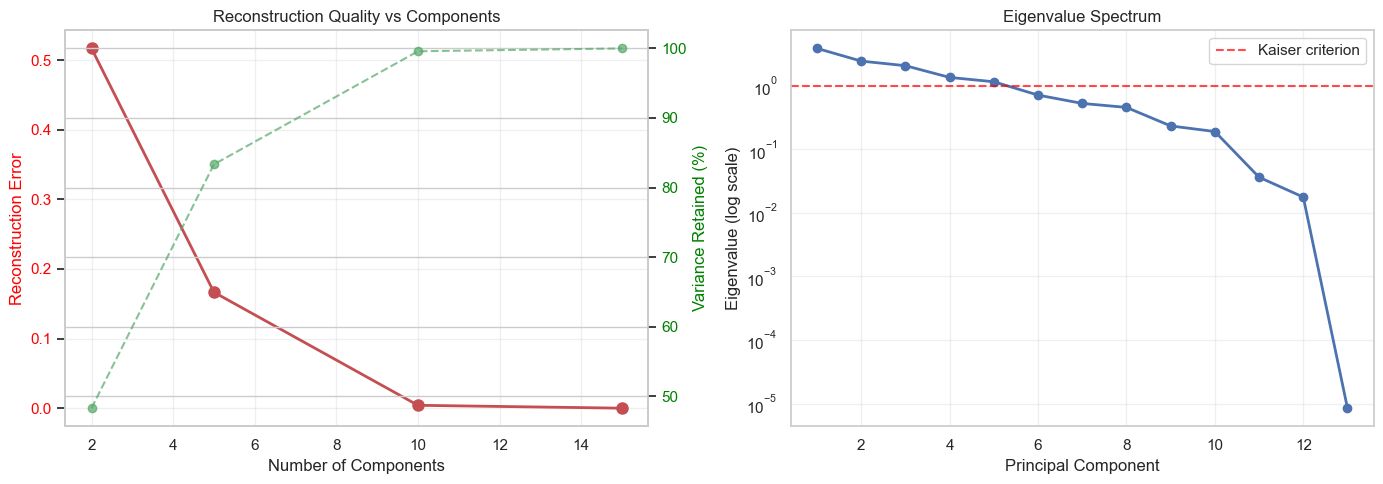

Quality plots show:
- Trade-off between reconstruction error and dimensionality
- Eigenvalue spectrum decay pattern
- Kaiser criterion threshold visualization
Dual-axis plot shows reconstruction vs. variance trade-off
Eigenvalue spectrum helps identify natural component cutoffs


In [ ]:
from utils import visualize_quality_metrics

print("\n" + "=" * 60)
print("QUALITY METRICS VISUALIZATION")
print("=" * 60)

# Create quality assessment visualizations
visualize_quality_metrics(quality_metrics, pca_results)

print(f"Dual-axis plot shows reconstruction vs. variance trade-off")
print(f"Eigenvalue spectrum helps identify natural component cutoffs")

### *Compare original vs reconstructed data for specific samples*


INDIVIDUAL SAMPLE RECONSTRUCTION

Reconstruction Quality for Individual Samples:


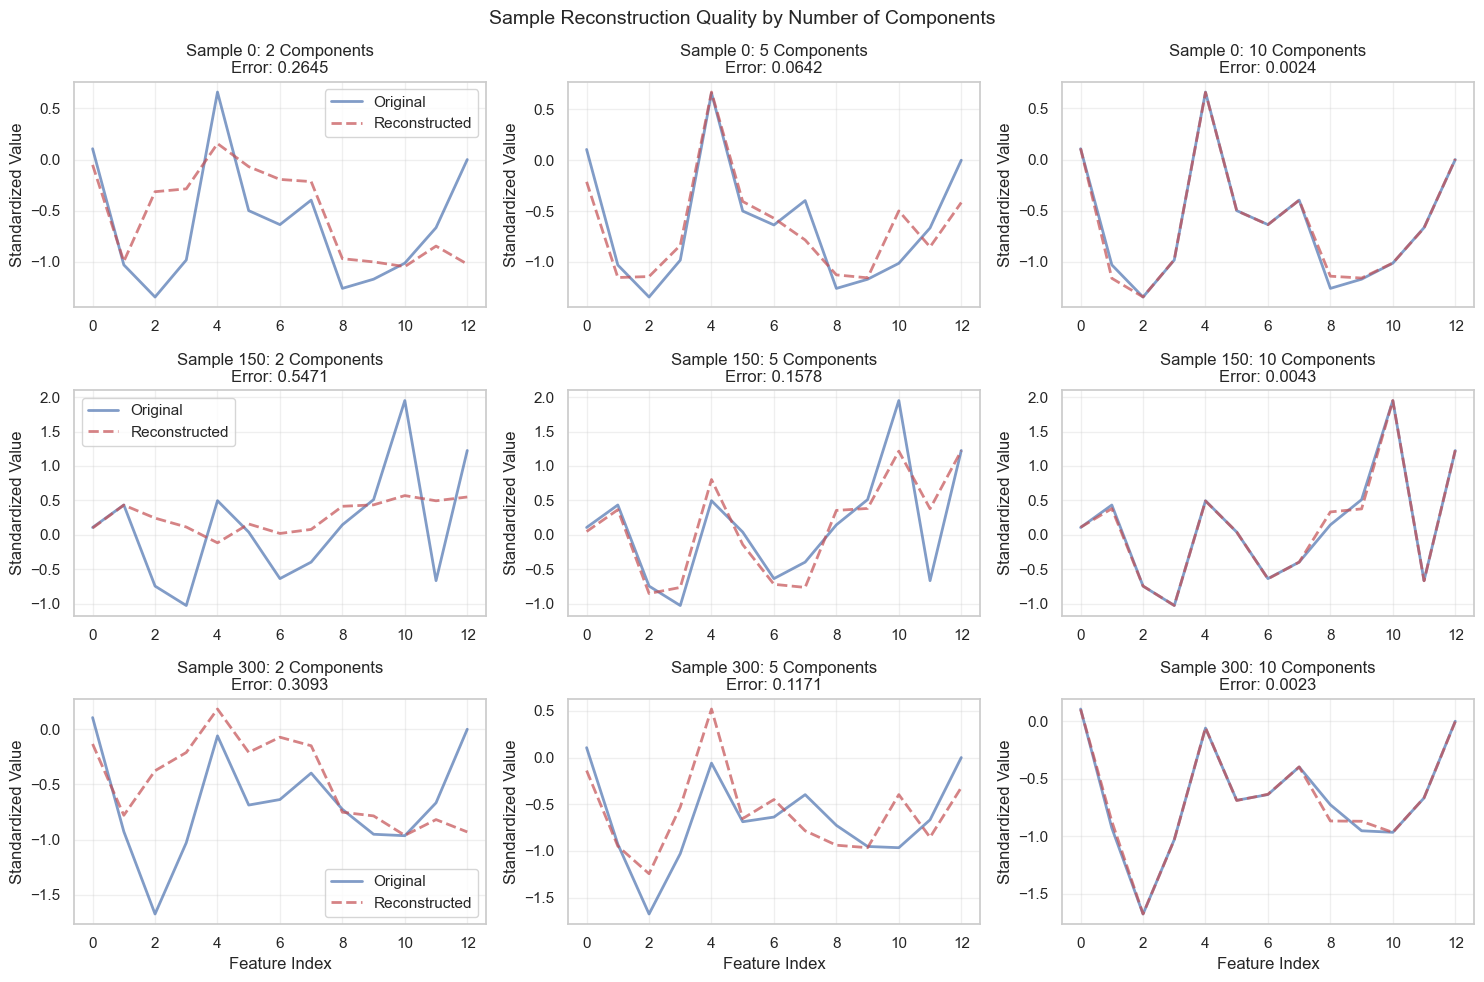

Shows how well PCA reconstructs individual data points
Blue lines = original data, Red dashed = reconstructed
Lower reconstruction error = better approximation


In [ ]:
from utils import compare_reconstruction_samples

print("\n" + "=" * 60)
print("INDIVIDUAL SAMPLE RECONSTRUCTION")
print("=" * 60)

# Compare reconstruction quality for specific samples
reconstruction_errors = compare_reconstruction_samples(X_scaled, pca_results, numerical_cols+['p_color'],
                                                     sample_indices=[0, 150, 300])

print(f"Shows how well PCA reconstructs individual data points")
print(f"Blue lines = original data, Red dashed = reconstructed")
print(f"Lower reconstruction error = better approximation")